<a href="https://colab.research.google.com/github/bdipesh3045/Data-Science-project-AI-Class-/blob/main/main2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kagglehub

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "sign_mnist_train.csv"


# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "datamunge/sign-language-mnist",
  file_path,

)



/tmp/ipykernel_1176/4036122750.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sign-language-mnist' dataset.


In [ ]:
# pip install xgboost

import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Load test data
test_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "datamunge/sign-language-mnist",
    "sign_mnist_test.csv"
)

X_train = df.drop(columns="label")
X_test = test_df[X_train.columns]

# XGBoost needs consecutive labels: 0, 1, ..., 23
encoder = LabelEncoder()
y_train = encoder.fit_transform(df["label"])
y_test = encoder.transform(test_df["label"])

# Train
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42
)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")

# Confusion matrix with alphabet letters
letters = [chr(65 + int(label)) for label in encoder.classes_]

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=range(len(letters)),
    display_labels=letters,
    cmap="Blues",
    ax=ax,
    colorbar=False
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1176/3900515280.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  test_df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sign-language-mnist' dataset.


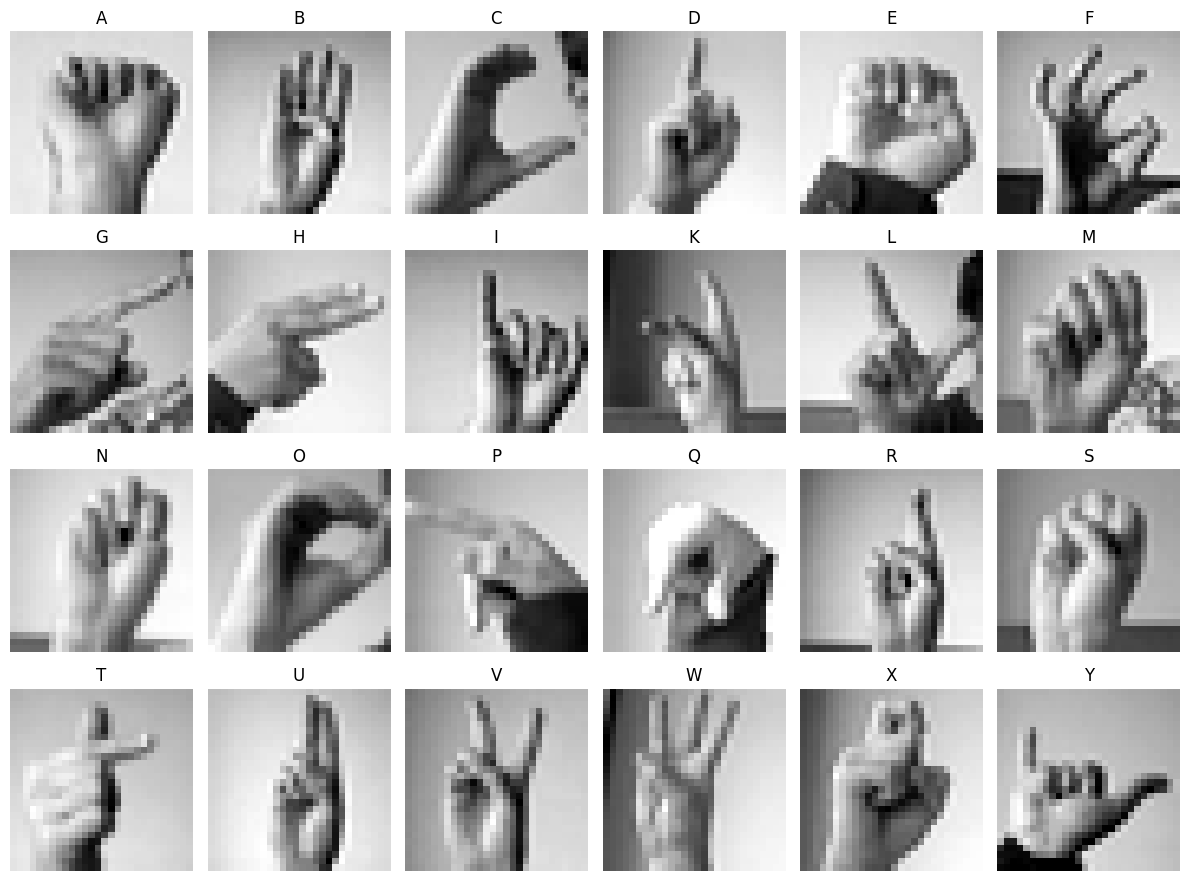

In [5]:
import matplotlib.pyplot as plt

labels = sorted(df["label"].unique())

plt.figure(figsize=(12, 9))

for i, label in enumerate(labels):
    row = df[df["label"] == label].iloc[0]
    image = row.drop("label").to_numpy().reshape(28, 28)

    plt.subplot(4, 6, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(chr(65 + int(label)))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

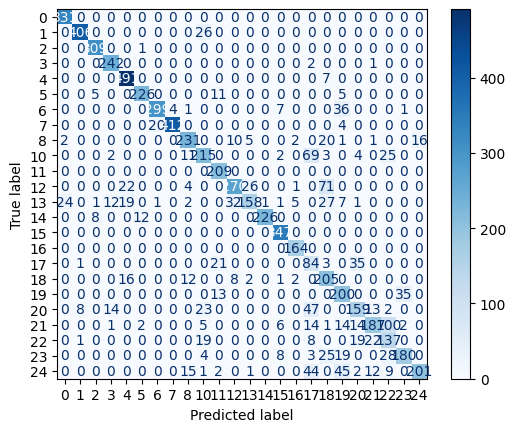

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.show()